# Can you trust the confidence?

Draw a digit that slowly turns from a 4 into a 9, and ask four decision APIs which one it is. Drawings A and B, in the middle, are nearly the same: a confidence you act on should say about the same thing for both.

This notebook reproduces the blog post [Can you trust the confidence?](https://typellm.ai/blog/confidence-4-or-9). It asks TypeLLM, OpenAI's Decisions API, and Cloudflare's Clef and Clef-flash through OpenRouter.

Paste your API keys in the cell below, then run all cells.

In [1]:
%pip install -q "typellm>=0.6.8" openai pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Paste your API keys here.
TYPELLM_API_KEY = ""     # https://typellm.ai/dashboard/keys
OPENAI_API_KEY = ""      # https://platform.openai.com/api-keys
OPENROUTER_API_KEY = ""  # https://openrouter.ai/settings/keys

## Draw the four digits

The head of the digit goes from a 4's closed triangle (`round_=0`) to a 9's loop (`round_=1`). Four, A, B and Nine sit at 0.25, 0.44, 0.48 and 0.75.

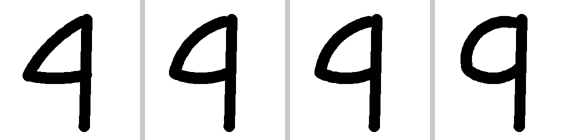

In [3]:
import math
from PIL import Image, ImageDraw

W, INK = 280, 22
STEM_X, TOP, BAR, BOTTOM = 62, 14, 56, 90

def head(round_):
    """The digit's head as one stroke: 0 a closed 4's triangle, 1 a 9's loop."""
    tri = [(STEM_X, TOP), (18, BAR), (STEM_X, BAR)]  # the slant, then the bar
    def along(path, u):  # a point a fraction u along a polyline
        seg = [math.dist(path[i], path[i + 1]) for i in range(len(path) - 1)]
        d = u * sum(seg)
        for i, l in enumerate(seg):
            if d <= l or i == len(seg) - 1:
                f = min(1, d / l)
                return (path[i][0] + f * (path[i + 1][0] - path[i][0]), path[i][1] + f * (path[i + 1][1] - path[i][1]))
            d -= l
    cx, cy, r = 40, 35, 21
    pts = []
    for i in range(61):
        u = i / 60
        a = along(tri, u)
        # the loop runs the same way: from the stem's top, over to the left, round the bottom, back to the stem
        ang = math.radians(60 + 270 * u)
        b = (STEM_X, TOP + 4) if u == 0 else (cx + r * math.cos(ang) + 2, cy - r * math.sin(ang))
        pts.append((a[0] * (1 - round_) + b[0] * round_, a[1] * (1 - round_) + b[1] * round_))
    return pts

def draw(round_):
    im = Image.new("L", (W, W), 255)
    d = ImageDraw.Draw(im)
    s = lambda p: (p[0] * W / 100, p[1] * W / 100)
    d.line([s((STEM_X, TOP)), s((STEM_X - 2, BOTTOM))], fill=0, width=INK)
    pts = [s(p) for p in head(round_)]
    d.line(pts, fill=0, width=INK, joint="curve")
    for p in pts + [s((STEM_X, TOP)), s((STEM_X - 2, BOTTOM))]:
        d.ellipse([p[0] - INK / 2, p[1] - INK / 2, p[0] + INK / 2, p[1] + INK / 2], fill=0)
    return im

DRAWINGS = {"Four": 0.25, "A": 0.44, "B": 0.48, "Nine": 0.75}
for name, round_ in DRAWINGS.items():
    draw(round_).save(f"{name}.png")

strip = Image.new("L", (4 * W + 30, W), 200)
for i, name in enumerate(DRAWINGS):
    strip.paste(Image.open(f"{name}.png"), (i * (W + 10), 0))
strip.resize((strip.width // 2, strip.height // 2))

## Ask each model

The same instruction and the same two options for every model. Clef's API asks for a description of each option, so its options read "The digit four" and "The digit nine"; OpenRouter is told to use Cloudflare, the model's own provider.

In [4]:
import base64, json, urllib.request
from openai import OpenAI
from typellm import TypeLLMClient

QUESTION = "Which digit is this handwritten character?"
typellm = TypeLLMClient(api_key=TYPELLM_API_KEY)
openai = OpenAI(api_key=OPENAI_API_KEY)

def data_url(path):
    return "data:image/png;base64," + base64.b64encode(open(path, "rb").read()).decode()

def ask_typellm(path):
    answer = typellm.generate(context="A handwritten digit.", images=[path], questions={"digit": {
        "type": "string", "enum": ["4", "9"], "return_probabilities": True, "instructions": QUESTION,
    }}).result["digit"]
    return answer["probabilities"]["4"]

def ask_openai(path):
    decision = openai.decisions.create(model="gpt-6-luna", input=[{"role": "user", "content": [
        {"type": "input_text", "text": "A handwritten digit."},
        {"type": "input_image", "image_url": data_url(path)},
    ]}], questions=[{"type": "choice", "name": "digit", "instructions": QUESTION,
                     "choices": [{"value": "4"}, {"value": "9"}]}])
    return {p.value: p.probability for p in decision.answers[0].probabilities}["4"]

def ask_openrouter(model):
    def ask(path):
        body = {"model": model, "provider": {"only": ["cloudflare"]},
                "questions": {"digit": {"type": "choice", "instructions": QUESTION,
                                        "criteria": {"4": "The digit four", "9": "The digit nine"}}},
                "state": [{"type": "text", "text": "A handwritten digit."},
                          {"type": "image_url", "image_url": {"url": data_url(path)}}]}
        request = urllib.request.Request("https://openrouter.ai/api/alpha/decisions", data=json.dumps(body).encode(),
            headers={"Authorization": f"Bearer {OPENROUTER_API_KEY}", "Content-Type": "application/json"})
        return json.load(urllib.request.urlopen(request, timeout=120))["answers"]["digit"]["probabilities"]["4"]
    return ask

MODELS = {"TypeLLM": ask_typellm, "OpenAI Decisions": ask_openai,
          "Clef": ask_openrouter("cloudflare/clef"), "Clef-flash": ask_openrouter("cloudflare/clef-flash")}

## The answers

For each model and drawing: the probability of a 4 and of a 9, the answer, and its confidence. With two options, the confidence is how far the top probability sits above an even split: `abs(2 * P(4) - 1)`.

In [5]:
results = {model: {name: ask(f"{name}.png") for name in DRAWINGS} for model, ask in MODELS.items()}

for name in DRAWINGS:
    print(f"{name}\n  {'':18s} {'P(4)':>6s} {'P(9)':>6s}  answer  confidence")
    for model, row in results.items():
        p4 = row[name]
        print(f"  {model:18s} {p4:6.2f} {1 - p4:6.2f}  {'4' if p4 > 0.5 else '9':>6s}  {abs(2 * p4 - 1):10.2f}")
    print()

Four
                       P(4)   P(9)  answer  confidence
  TypeLLM              1.00   0.00       4        1.00
  OpenAI Decisions     0.98   0.02       4        0.96
  Clef                 0.99   0.01       4        0.99
  Clef-flash           0.99   0.01       4        0.99

A
                       P(4)   P(9)  answer  confidence
  TypeLLM              0.47   0.53       9        0.06
  OpenAI Decisions     0.73   0.27       4        0.46
  Clef                 0.18   0.82       9        0.64
  Clef-flash           0.53   0.47       4        0.06

B
                       P(4)   P(9)  answer  confidence
  TypeLLM              0.41   0.59       9        0.18
  OpenAI Decisions     0.05   0.95       9        0.90
  Clef                 0.17   0.83       9        0.66
  Clef-flash           0.09   0.91       9        0.82

Nine
                       P(4)   P(9)  answer  confidence
  TypeLLM              0.00   1.00       9        0.99
  OpenAI Decisions     0.00   1.00       9      

## At a threshold

Act on answers with a confidence of 0.8 or more, and send the rest to a person. A and B look nearly the same; the ones handled differently are worth a look.

In [6]:
for model, row in results.items():
    def route(p4):
        return "to a person" if abs(2 * p4 - 1) < 0.8 else f"filed as {'4' if p4 > 0.5 else '9'}"
    print(f"{model:18s} A: {route(row['A']):12s}  B: {route(row['B'])}")

TypeLLM            A: to a person   B: to a person
OpenAI Decisions   A: to a person   B: filed as 9
Clef               A: to a person   B: to a person
Clef-flash         A: to a person   B: filed as 9
